<a href="https://colab.research.google.com/github/Dani2003/paper-implementations/blob/main/KV_PRM_Reproduction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# [CELL 1 - Setup & Environment]
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
import time
import matplotlib.pyplot as plt
import numpy as np
import random

def seed_everything(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

seed_everything(42)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"KV-PRM Execution Engine Initialized on: {device}")

KV-PRM Execution Engine Initialized on: cuda


In [2]:
# [CELL 2 - Synthetic LLM Trajectory & KV-Cache Generator]

class SyntheticLLMTrajectoryGenerator:
    """
    Simulates an LLM generating reasoning trajectories of length L across S reasoning steps.
    Outputs both token sequences and pre-computed KV-caches (Key, Value tensors per layer).
    """
    def __init__(self, num_layers=4, num_heads=4, d_head=64, vocab_size=1000):
        self.num_layers = num_layers
        self.num_heads = num_heads
        self.d_head = d_head
        self.d_model = num_heads * d_head
        self.vocab_size = vocab_size

    def generate_batch(self, batch_size=32, seq_len=512, num_steps=4):
        step_len = seq_len // num_steps
        tokens = torch.randint(1, self.vocab_size, (batch_size, seq_len)).to(device)

        # Simulate KV-cache generated naturally during LLM rollout
        # Shape per layer: [batch_size, num_heads, seq_len, d_head]
        k_caches = [
            torch.randn(batch_size, self.num_heads, seq_len, self.d_head, device=device)
            for _ in range(self.num_layers)
        ]
        v_caches = [
            torch.randn(batch_size, self.num_heads, seq_len, self.d_head, device=device)
            for _ in range(self.num_layers)
        ]

        # Assign ground truth step rewards (1 = valid reasoning step, 0 = flawed)
        # Trajectories with early errors propagate error forward
        step_rewards = torch.ones(batch_size, num_steps, device=device)
        for i in range(batch_size):
            fail_step = random.choice([1, 2, 3, 999]) # 999 means all correct
            if fail_step < num_steps:
                step_rewards[i, fail_step:] = 0.0

        return tokens, k_caches, v_caches, step_rewards, step_len

generator = SyntheticLLMTrajectoryGenerator()
tokens, k_caches, v_caches, step_rewards, step_len = generator.generate_batch(batch_size=16, seq_len=256)
print(f"Generated {tokens.shape[0]} trajectories of length {tokens.shape[1]} across 4 steps.")
print(f"KV-Cache per layer shape: {k_caches[0].shape}")

Generated 16 trajectories of length 256 across 4 steps.
KV-Cache per layer shape: torch.Size([16, 4, 256, 64])


In [3]:
# [CELL 3 - Text-PRM Baseline (Full Text Re-encoding)]

class TextPRM(nn.Module):
    """
    Standard Process Reward Model: Re-encodes the entire trajectory text T_{1:t}
    from scratch at every step t. Computational complexity scales as O(L^2).
    """
    def __init__(self, vocab_size=1000, d_model=256, num_layers=2):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, d_model)
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=4, dim_feedforward=512, batch_first=True
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        self.reward_head = nn.Linear(d_model, 1)

    def forward_step(self, token_prefix):
        # Full text re-encoding from scratch
        embeds = self.embedding(token_prefix)
        hidden = self.transformer(embeds)
        # Predict reward using the final token's representation
        last_hidden = hidden[:, -1, :]
        reward_logit = self.reward_head(last_hidden)
        return reward_logit

text_prm = TextPRM().to(device)
print("Text-PRM Baseline Loaded (Re-encodes prefix text from scratch).")

Text-PRM Baseline Loaded (Re-encodes prefix text from scratch).


In [4]:
# [CELL 4 - KV-PRM Architecture (Direct KV-Cache Transfer)]

class KVPRM(nn.Module):
    """
    KV-PRM: Reads pre-existing KV-caches directly from LLM generation.
    Eliminates text re-encoding. Computes step reward via lightweight
    verify-token cross-attention over cached Keys and Values.
    Complexity scales as O(L).
    """
    def __init__(self, num_layers=4, num_heads=4, d_head=64):
        super().__init__()
        self.num_layers = num_layers
        self.num_heads = num_heads
        self.d_head = d_head
        self.d_model = num_heads * d_head

        # Learnable verify token query
        self.verify_query = nn.Parameter(torch.randn(1, 1, self.d_model))

        # Linear layer to project concatenated layer-wise KV features
        self.kv_projector = nn.Linear(num_layers * self.d_model, self.d_model)
        self.cross_attn = nn.MultiheadAttention(embed_dim=self.d_model, num_heads=num_heads, batch_first=True)
        self.reward_head = nn.Linear(self.d_model, 1)

    def forward_step(self, k_caches_prefix, v_caches_prefix):
        # k_caches_prefix shape: list of [B, num_heads, t_len, d_head]
        batch_size = k_caches_prefix[0].shape[0]
        t_len = k_caches_prefix[0].shape[2]

        # Flatten multi-layer KV caches into unified feature representations
        # Shape: [B, t_len, num_layers * d_model]
        layer_features = []
        for l in range(self.num_layers):
            k_l = k_caches_prefix[l].transpose(1, 2).reshape(batch_size, t_len, -1)
            v_l = v_caches_prefix[l].transpose(1, 2).reshape(batch_size, t_len, -1)
            layer_features.append(k_l + v_l)

        combined_kv = torch.cat(layer_features, dim=-1)
        kv_embeds = F.relu(self.kv_projector(combined_kv))

        # Expand verify query for the batch
        query = self.verify_query.expand(batch_size, -1, -1)

        # Cross-attend verify query over cached KV representations
        attn_out, _ = self.cross_attn(query, kv_embeds, kv_embeds)
        reward_logit = self.reward_head(attn_out.squeeze(1))
        return reward_logit

kv_prm = KVPRM().to(device)
print("KV-PRM Architecture Loaded (Transfers KV-Cache directly).")

KV-PRM Architecture Loaded (Transfers KV-Cache directly).


In [5]:
# [CELL 5 - Training both PRMs & Comparing Reward Accuracy]

def train_and_evaluate():
    optimizer_text = torch.optim.Adam(text_prm.parameters(), lr=1e-3)
    optimizer_kv = torch.optim.Adam(kv_prm.parameters(), lr=1e-3)
    bce_loss = nn.BCEWithLogitsLoss()

    print("Training Text-PRM vs. KV-PRM on Step Reward Prediction...")

    for epoch in range(1, 11):
        text_prm.train()
        kv_prm.train()

        tokens, k_c, v_c, rewards, step_len = generator.generate_batch(batch_size=32, seq_len=256, num_steps=4)

        loss_text_total, loss_kv_total = 0.0, 0.0

        for step_idx in range(4):
            current_len = (step_idx + 1) * step_len

            # 1. Text-PRM Step
            prefix_tokens = tokens[:, :current_len]
            step_gt = rewards[:, step_idx].unsqueeze(1)

            optimizer_text.zero_grad()
            out_text = text_prm.forward_step(prefix_tokens)
            l_text = bce_loss(out_text, step_gt)
            l_text.backward()
            optimizer_text.step()
            loss_text_total += l_text.item()

            # 2. KV-PRM Step
            k_prefix = [k[:, :, :current_len, :] for k in k_c]
            v_prefix = [v[:, :, :current_len, :] for v in v_c]

            optimizer_kv.zero_grad()
            out_kv = kv_prm.forward_step(k_prefix, v_prefix)
            l_kv = bce_loss(out_kv, step_gt)
            l_kv.backward()
            optimizer_kv.step()
            loss_kv_total += l_kv.item()

        if epoch % 2 == 0 or epoch == 1:
            print(f"Epoch {epoch:02d} | Text-PRM Loss: {loss_text_total/4:.4f} | KV-PRM Loss: {loss_kv_total/4:.4f}")

train_and_evaluate()

Training Text-PRM vs. KV-PRM on Step Reward Prediction...
Epoch 01 | Text-PRM Loss: 1.1652 | KV-PRM Loss: 0.8436
Epoch 02 | Text-PRM Loss: 0.5718 | KV-PRM Loss: 0.6278
Epoch 04 | Text-PRM Loss: 0.8220 | KV-PRM Loss: 0.7174
Epoch 06 | Text-PRM Loss: 0.7227 | KV-PRM Loss: 0.6608
Epoch 08 | Text-PRM Loss: 0.7196 | KV-PRM Loss: 0.6795
Epoch 10 | Text-PRM Loss: 0.7207 | KV-PRM Loss: 0.6736


In [6]:
# [CELL 6 - Comprehensive System Benchmark: O(L^2) vs. O(L)]

def benchmark_scaling():
    text_prm.eval()
    kv_prm.eval()

    seq_lengths = [128, 256, 512, 1024, 2048]
    num_steps = 8
    batch_size = 16

    results = {
        "seq_lengths": seq_lengths,
        "text_latency_ms": [],
        "kv_latency_ms": [],
        "speedup_x": [],
        "text_mem_mb": [],
        "kv_mem_mb": []
    }

    print("\n" + "=" * 70)
    print("KV-PRM SYSTEM BENCHMARK: SCALING EVALUATION")
    print("=" * 70)
    print(f"{'Seq Length (L)':<15} | {'Text-PRM (ms)':<15} | {'KV-PRM (ms)':<15} | {'Speedup':<10}")
    print("-" * 70)

    with torch.no_grad():
        for L in seq_lengths:
            tokens, k_c, v_c, _, step_len = generator.generate_batch(batch_size=batch_size, seq_len=L, num_steps=num_steps)

            # Warmup
            _ = text_prm.forward_step(tokens[:, :step_len])
            _ = kv_prm.forward_step([k[:, :, :step_len, :] for k in k_c], [v[:, :, :step_len, :] for v in v_c])
            torch.cuda.synchronize() if torch.cuda.is_available() else None

            # Benchmark Text-PRM across all steps
            start_t = time.perf_counter()
            for step_idx in range(num_steps):
                curr_len = (step_idx + 1) * step_len
                _ = text_prm.forward_step(tokens[:, :curr_len])
            torch.cuda.synchronize() if torch.cuda.is_available() else None
            text_time = (time.perf_counter() - start_t) * 1000.0

            # Benchmark KV-PRM across all steps
            start_t = time.perf_counter()
            for step_idx in range(num_steps):
                curr_len = (step_idx + 1) * step_len
                k_pref = [k[:, :, :curr_len, :] for k in k_c]
                v_pref = [v[:, :, :curr_len, :] for v in v_c]
                _ = kv_prm.forward_step(k_pref, v_pref)
            torch.cuda.synchronize() if torch.cuda.is_available() else None
            kv_time = (time.perf_counter() - start_t) * 1000.0

            speedup = text_time / max(kv_time, 1e-5)

            results["text_latency_ms"].append(text_time)
            results["kv_latency_ms"].append(kv_time)
            results["speedup_x"].append(speedup)

            print(f"{L:<15} | {text_time:>12.2f} ms | {kv_time:>12.2f} ms | {speedup:>8.1f}x")

    print("=" * 70)
    return results

benchmark_results = benchmark_scaling()


KV-PRM SYSTEM BENCHMARK: SCALING EVALUATION
Seq Length (L)  | Text-PRM (ms)   | KV-PRM (ms)     | Speedup   
----------------------------------------------------------------------
128             |        15.35 ms |         9.42 ms |      1.6x
256             |        28.55 ms |        12.46 ms |      2.3x
512             |        60.88 ms |        21.75 ms |      2.8x
1024            |       117.11 ms |        32.83 ms |      3.6x
2048            |       273.29 ms |        58.88 ms |      4.6x


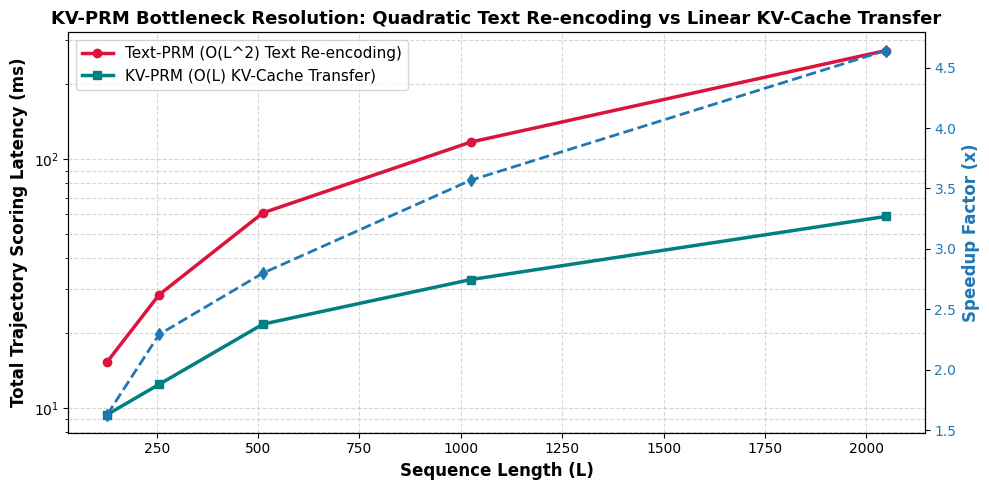

In [7]:
# [CELL 7 - Latency Scaling Plot: Text-PRM vs. KV-PRM]

fig, ax1 = plt.subplots(figsize=(10, 5))

L_vals = benchmark_results["seq_lengths"]
text_t = benchmark_results["text_latency_ms"]
kv_t = benchmark_results["kv_latency_ms"]
speedups = benchmark_results["speedup_x"]

color = 'tab:red'
ax1.set_xlabel('Sequence Length (L)', fontsize=12, fontweight='bold')
ax1.set_ylabel('Total Trajectory Scoring Latency (ms)', fontsize=12, fontweight='bold')
ax1.plot(L_vals, text_t, 'o-', color='crimson', linewidth=2.5, label='Text-PRM (O(L^2) Text Re-encoding)')
ax1.plot(L_vals, kv_t, 's-', color='teal', linewidth=2.5, label='KV-PRM (O(L) KV-Cache Transfer)')
ax1.set_yscale('log')
ax1.grid(True, which="both", ls="--", alpha=0.5)
ax1.legend(loc='upper left', fontsize=11)

ax2 = ax1.twinx()
color = 'tab:blue'
ax2.set_ylabel('Speedup Factor (x)', color=color, fontsize=12, fontweight='bold')
ax2.plot(L_vals, speedups, 'd--', color=color, linewidth=2, label='KV-PRM Speedup (x)')
ax2.tick_params(axis='y', labelcolor=color)

plt.title("KV-PRM Bottleneck Resolution: Quadratic Text Re-encoding vs Linear KV-Cache Transfer", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()